In [1]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# Step 2: Load the Dataset

file_path = r"C:\Users\hp\Desktop\calibo\Supervised_Learning_Messy_Customer_Churn.csv"

df = pd.read_csv(file_path)

df.head()

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [3]:
# Step 3: Problem Statement

print("Problem Statement:")
print("Can we divide customers into groups based on their usage patterns?")

Problem Statement:
Can we divide customers into groups based on their usage patterns?


In [4]:
# Check number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 184
Number of columns: 13


In [5]:
# Display column names

print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Customer_ID', 'Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score', 'Contract_Type', 'Payment_Method', 'Region', 'Plan_Type', 'Churn']


In [6]:
# Check data types

df.dtypes

Customer_ID                  str
Age                      float64
Annual_Income                str
Tenure_Months            float64
Monthly_Charges          float64
Support_Calls_Last_3M    float64
Data_Usage_GB            float64
Satisfaction_Score       float64
Contract_Type                str
Payment_Method               str
Region                       str
Plan_Type                    str
Churn                        str
dtype: object

In [7]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            184 non-null    str    
 1   Age                    176 non-null    float64
 2   Annual_Income          173 non-null    str    
 3   Tenure_Months          177 non-null    float64
 4   Monthly_Charges        178 non-null    float64
 5   Support_Calls_Last_3M  179 non-null    float64
 6   Data_Usage_GB          178 non-null    float64
 7   Satisfaction_Score     178 non-null    float64
 8   Contract_Type          184 non-null    str    
 9   Payment_Method         184 non-null    str    
 10  Region                 184 non-null    str    
 11  Plan_Type              184 non-null    str    
 12  Churn                  184 non-null    str    
dtypes: float64(6), str(7)
memory usage: 18.8 KB


In [8]:
# Statistical summary of numerical columns

df.describe()

,Age,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score
count,176.000000,177.000000,178.000000,179.000000,178.000000,178.000000
mean,36.164773,39.395480,80.205899,3.217877,17.806180,5.803371
std,12.865951,21.545185,74.179370,2.577455,9.245516,2.947869
min,-5.000000,1.000000,0.000000,0.000000,-10.000000,1.000000
25%,29.000000,25.000000,57.885000,2.000000,11.600000,4.000000
50%,36.000000,38.000000,73.565000,3.000000,18.200000,6.000000
75%,41.000000,55.000000,90.280000,4.000000,24.200000,8.000000
max,145.000000,150.000000,999.000000,30.000000,44.000000,15.000000


In [9]:
# First 5 rows

display(df.head())

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
0,CUST-1020,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,Yes
1,CUST-1043,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,Yes
2,CUST-1157,55.0,NaN,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,Yes
3,CUST-1112,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,Yes
4,CUST-1149,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,Yes


In [10]:
# Last 5 rows

display(df.tail())

,Customer_ID,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Churn
179,CUST-1107,55.0,54100.0,68.0,99.59,6.0,21.5,8.0,1 Year,Bank Transfer,East,Basic,Yes
180,CUST-1015,19.0,63000.0,NaN,64.24,1.0,13.0,7.0,Monthly,Credit Card,south,Premium,Yes
181,CUST-1093,29.0,45300.0,69.0,67.48,1.0,10.6,6.0,Monthly,Debit Card,East,Standard,No
182,CUST-1180,63.0,47100.0,45.0,65.58,0.0,11.3,1.0,Monthly,UPI,East,Standard,Yes
183,CUST-1103,NaN,48300.0,13.0,94.69,0.0,16.8,1.0,2 Year,Bank Transfer,West,Standard,No


In [11]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64


In [12]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 4


In [13]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (180, 13)


## Step 5: Check Missing Values


In [14]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)


Missing values in each column:
Customer_ID               0
Age                       8
Annual_Income            11
Tenure_Months             7
Monthly_Charges           6
Support_Calls_Last_3M     5
Data_Usage_GB             6
Satisfaction_Score        6
Contract_Type             0
Payment_Method            0
Region                    0
Plan_Type                 0
Churn                     0
dtype: int64


## Step 6: Check Unique Values for Categorical Features


In [15]:
# Check unique values for categorical columns

categorical_columns = df.select_dtypes(
    include=["object", "category", "string"]
).columns

for column in categorical_columns:
    print("\n" + column)
    print(df[column].unique())



Customer_ID
<StringArray>
['CUST-1020', 'CUST-1043', 'CUST-1157', 'CUST-1112', 'CUST-1149', 'CUST-1016',
 'CUST-1025', 'CUST-1069', 'CUST-1118', 'CUST-1099',
 ...
 'CUST-1088', 'CUST-1075', 'CUST-1122', 'CUST-1021', 'CUST-1072', 'CUST-1107',
 'CUST-1015', 'CUST-1093', 'CUST-1180', 'CUST-1103']
Length: 180, dtype: str

Annual_Income
<StringArray>
[ '23800.0',  '69400.0',        nan,  '80000.0',  '95700.0',  '88000.0',
  '49100.0',  '69200.0',  '43300.0',  '59800.0',
 ...
  '54200.0',  '37900.0',  '71300.0',  '79200.0', '100400.0',  '54100.0',
  '63000.0',  '45300.0',  '47100.0',  '48300.0']
Length: 157, dtype: str

Contract_Type
<StringArray>
['MONTHLY', 'Monthly', '1 Year', '2 Year', '2-Year', '1 year', 'monthly', '?']
Length: 8, dtype: str

Payment_Method
<StringArray>
['Bank Transfer',           'UPI',    'Debit Card',   'Credit Card',
             '?', 'bank transfer',           'upi',       'Unknown',
   'Credit card']
Length: 9, dtype: str

Region
<StringArray>
['North', 'South',

## Step 7: Identify Numerical Features


In [16]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)


Numerical columns:
['Age', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']


## Step 8: Correlation Heatmap

The correlation heatmap helps us understand relationships among numerical customer features before clustering.


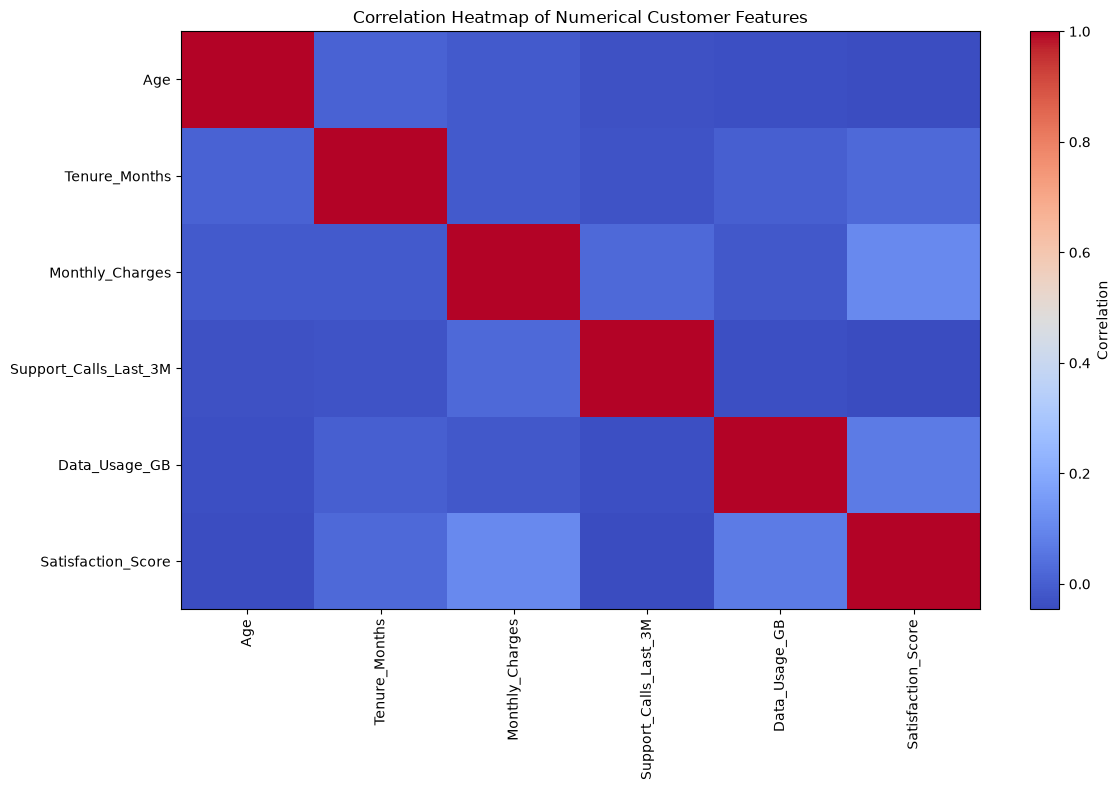

In [17]:
# Correlation Heatmap

numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of Numerical Customer Features")
plt.tight_layout()
plt.show()


## Step 9: Box Plots

Box plots are used to understand the distribution of numerical features and identify possible extreme values.


C:\Users\hp\AppData\Local\Temp\ipykernel_16588\2013466831.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


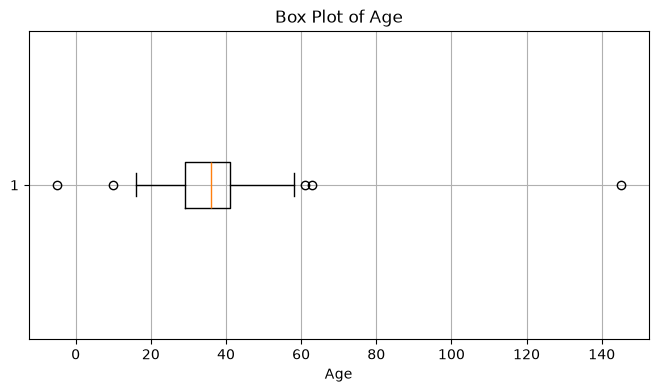

C:\Users\hp\AppData\Local\Temp\ipykernel_16588\2013466831.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


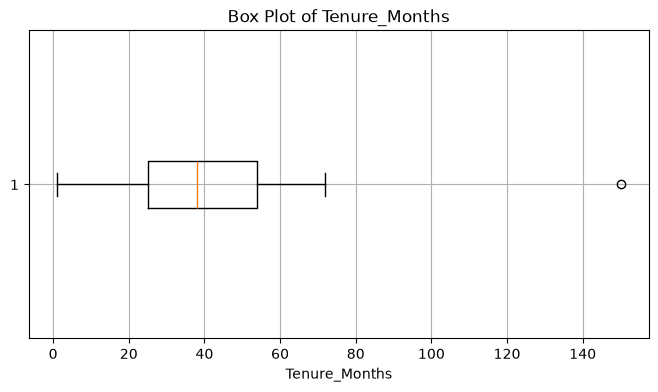

C:\Users\hp\AppData\Local\Temp\ipykernel_16588\2013466831.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


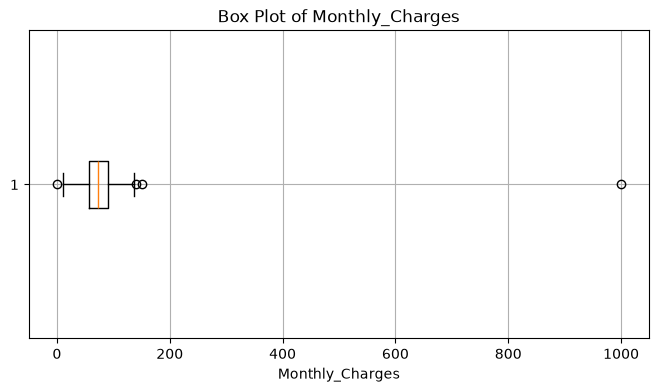

C:\Users\hp\AppData\Local\Temp\ipykernel_16588\2013466831.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


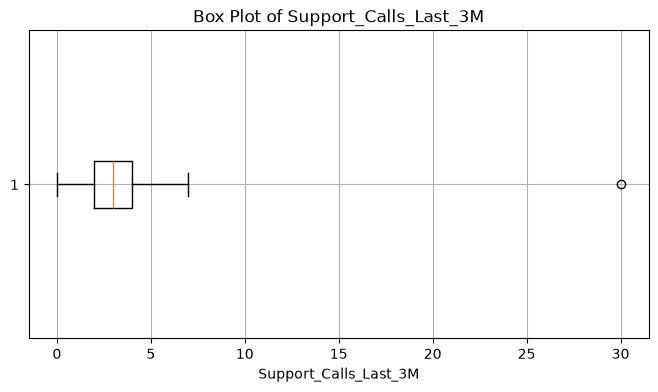

C:\Users\hp\AppData\Local\Temp\ipykernel_16588\2013466831.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


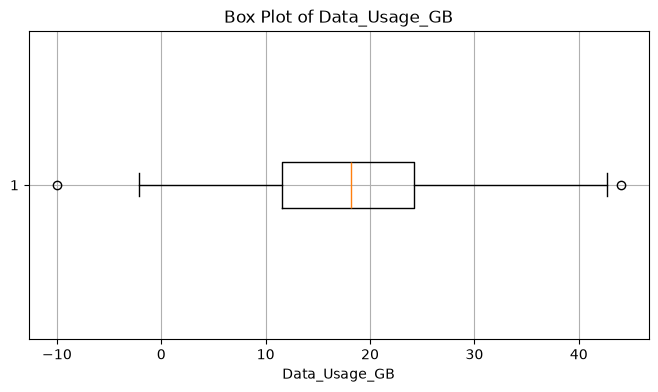

C:\Users\hp\AppData\Local\Temp\ipykernel_16588\2013466831.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


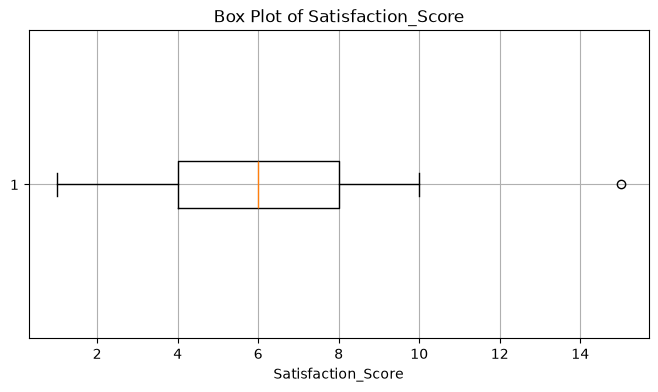

In [18]:
# Box plots for numerical features

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.xlabel(column)
    plt.title(f"Box Plot of {column}")
    plt.grid(True)

    plt.show()


## Step 10: Outlier Detection Using IQR

The Interquartile Range (IQR) method is used to identify possible outliers.

- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR


In [19]:
# Outlier detection using IQR

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": int(outlier_mask.sum())
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary.round(2))


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Age,29.00,41.00,12.00,11.0,59.00,5
1,Tenure_Months,25.00,54.00,29.00,-18.5,97.50,1
2,Monthly_Charges,57.46,90.03,32.57,8.6,138.89,4
3,Support_Calls_Last_3M,2.00,4.00,2.00,-1.0,7.00,1
4,Data_Usage_GB,11.60,24.20,12.60,-7.3,43.10,2
5,Satisfaction_Score,4.00,8.00,4.00,-2.0,14.00,1


## Step 11: Handle Outliers Using IQR Capping

We cap extreme numerical values at the IQR boundaries instead of deleting customer records.
This keeps the observations while reducing the effect of extreme values on distance-based K-Means clustering.


In [20]:
# Handle outliers using IQR capping

df_clean = df.copy()

for column in numerical_columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("Outliers handled using IQR capping.")


Outliers handled using IQR capping.


## Step 12: Continue With the Cleaned Dataset


In [21]:
# Use the cleaned dataset for the remaining preprocessing steps

df = df_clean.copy()

print("Dataset shape after outlier handling:", df.shape)
print("Total missing values:", df.isnull().sum().sum())


Dataset shape after outlier handling: (180, 13)
Total missing values: 49


## Step 13: Problem Statement

**Can we divide customers into groups based on their usage patterns?**


In [22]:
# Problem Statement

print("Problem Statement:")
print("Can we divide customers into groups based on their usage patterns?")


Problem Statement:
Can we divide customers into groups based on their usage patterns?


## Step 14: Remove Unnecessary Columns

- `Customer_ID` is an identifier and is not useful for clustering.
- `Churn` is a target/label, so it is not used in unsupervised learning.


In [23]:
# Remove unnecessary columns

columns_to_remove = []

if "Customer_ID" in df.columns:
    columns_to_remove.append("Customer_ID")

if "Churn" in df.columns:
    columns_to_remove.append("Churn")

df_model = df.drop(
    columns=columns_to_remove,
    errors="ignore"
).copy()

print("Removed columns:", columns_to_remove)
print("Shape after removing unnecessary columns:", df_model.shape)


Removed columns: ['Customer_ID', 'Churn']
Shape after removing unnecessary columns: (180, 11)


## Step 15: Convert Annual Income to Numeric


In [24]:
# Convert Annual_Income to numeric safely

if "Annual_Income" in df_model.columns:

    df_model["Annual_Income"] = (
        df_model["Annual_Income"]
        .astype("string")
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )

    df_model["Annual_Income"] = pd.to_numeric(
        df_model["Annual_Income"],
        errors="coerce"
    )

print("Annual_Income data type:")
if "Annual_Income" in df_model.columns:
    print(df_model["Annual_Income"].dtype)


Annual_Income data type:
Float64


## Step 16: Separate Numerical and Categorical Features


In [25]:
# Identify feature types

numerical_features = df_model.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = df_model.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Charges', 'Support_Calls_Last_3M', 'Data_Usage_GB', 'Satisfaction_Score']

Categorical features:
['Contract_Type', 'Payment_Method', 'Region', 'Plan_Type']


## Step 17: Handle Remaining Missing Values


In [26]:
# Handle numerical missing values with median
for column in numerical_features:
    df_model[column] = df_model[column].fillna(
        df_model[column].median()
    )

# Handle categorical missing values with mode
for column in categorical_features:

    mode_value = df_model[column].mode(dropna=True)

    if not mode_value.empty:
        df_model[column] = df_model[column].fillna(
            mode_value.iloc[0]
        )

print(
    "Total missing values after handling:",
    df_model.isnull().sum().sum()
)


Total missing values after handling: 0


## Step 18: Feature Selection

The main usage-related numerical features are selected when available.


In [27]:
# Select usage-related numerical features

preferred_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months",
    "Age",
    "Satisfaction_Score",
    "Annual_Income"
]

selected_features = [
    feature
    for feature in preferred_features
    if feature in df_model.columns
]

print("Selected numerical features:")
print(selected_features)


Selected numerical features:
['Monthly_Charges', 'Data_Usage_GB', 'Support_Calls_Last_3M', 'Tenure_Months', 'Age', 'Satisfaction_Score', 'Annual_Income']


## Step 19: Prepare Data for Encoding


In [28]:
# Prepare model input

model_input = df_model[
    selected_features + categorical_features
].copy()

print("Shape before encoding:", model_input.shape)


Shape before encoding: (180, 11)


## Step 20: Encode Categorical Features

Categorical values are converted into numerical variables using one-hot encoding.


In [29]:
# One-hot encode categorical features

X = pd.get_dummies(
    model_input,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", X.shape)

print("\nRemaining categorical columns:")
print(
    X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)


Shape after encoding: (180, 34)

Remaining categorical columns:
[]


## Step 21: Final Data Validation Before Scaling


In [30]:
# Replace infinite values if any
X = X.replace([np.inf, -np.inf], np.nan)

# Fill any remaining missing values
for column in X.columns:
    if X[column].isnull().any():
        X[column] = X[column].fillna(
            X[column].median()
        )

print("Shape:", X.shape)
print("Total missing values:", X.isnull().sum().sum())
print(
    "Remaining categorical columns:",
    X.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)


Shape: (180, 34)
Total missing values: 0
Remaining categorical columns: []


## Step 22: Feature Scaling

K-Means is distance-based, so the features are standardized before clustering.


In [31]:
# Feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (180, 34)


## Step 23: Final Data Validation


In [32]:
# Final validation

print("Shape:", X_scaled.shape)
print("Total missing values:", np.isnan(X_scaled).sum())
print("Total infinite values:", np.isinf(X_scaled).sum())


Shape: (180, 34)
Total missing values: 0
Total infinite values: 0


## Step 24: Elbow Method


In [33]:
# Elbow Method

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
K_range = range(2, 11)

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

print("Inertia values:")

for k, value in zip(K_range, inertia):
    print(f"K = {k}: {value:.2f}")


Inertia values:
K = 2: 5854.99
K = 3: 5599.89
K = 4: 5337.57
K = 5: 5146.40
K = 6: 4951.29
K = 7: 4855.35
K = 8: 4679.01
K = 9: 4371.56
K = 10: 4235.83


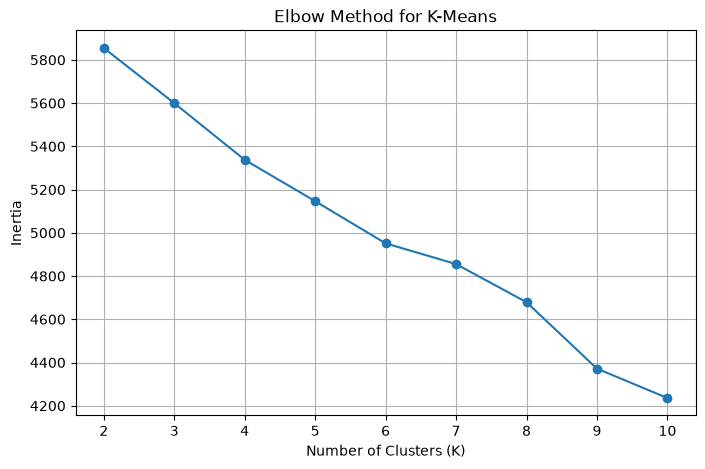

In [34]:
# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()


## Step 25: Silhouette Score


In [35]:
# Calculate silhouette scores

silhouette_scores = []

for k in K_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )


K = 2, Silhouette Score = 0.0600
K = 3, Silhouette Score = 0.0834
K = 4, Silhouette Score = 0.0880
K = 5, Silhouette Score = 0.0699
K = 6, Silhouette Score = 0.0945
K = 7, Silhouette Score = 0.0640
K = 8, Silhouette Score = 0.0635
K = 9, Silhouette Score = 0.0811
K = 10, Silhouette Score = 0.0946


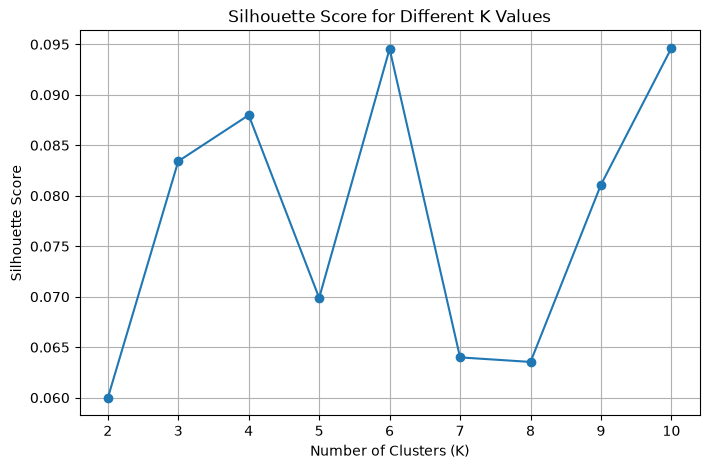

In [36]:
# Plot Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()


## Step 26: Select the Final Number of Clusters

For this dataset, the notebook compares the silhouette scores and then uses the practical K selected for the customer segmentation analysis.


In [37]:
# Select the practical K used in the customer segmentation

best_k = 4

print("Selected K:", best_k)

selected_score = silhouette_scores[
    list(K_range).index(best_k)
]

print(
    "Silhouette Score for selected K:",
    round(selected_score, 4)
)


Selected K: 4
Silhouette Score for selected K: 0.088


## Step 27: Train the Final K-Means Model


In [38]:
# Train final K-Means model

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(
    X_scaled
)

print("Final K-Means model trained successfully.")


Final K-Means model trained successfully.


## Step 28: Add Cluster Labels


In [39]:
# Add cluster labels to the cleaned dataset

df_clustered = df_model.copy()
df_clustered["Cluster"] = cluster_labels

display(df_clustered.head())


,Age,Annual_Income,Tenure_Months,Monthly_Charges,Support_Calls_Last_3M,Data_Usage_GB,Satisfaction_Score,Contract_Type,Payment_Method,Region,Plan_Type,Cluster
0,22.0,23800.0,11.0,62.96,7.0,20.4,5.0,MONTHLY,Bank Transfer,North,Standard,0
1,35.0,69400.0,17.0,75.63,6.0,17.5,9.0,Monthly,Bank Transfer,South,Basic,2
2,55.0,64400.0,49.0,92.85,3.0,21.6,1.0,Monthly,UPI,West,Basic,3
3,36.0,80000.0,9.0,85.67,0.0,34.3,9.0,Monthly,UPI,South,Standard,2
4,41.0,95700.0,51.0,60.77,1.0,23.7,9.0,Monthly,Debit Card,West,Premium,3


## Step 29: Cluster Sizes


In [40]:
# Count customers in each cluster

cluster_counts = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each cluster:")
print(cluster_counts)


Customers in each cluster:
Cluster
0    50
1    35
2    49
3    46
Name: count, dtype: int64


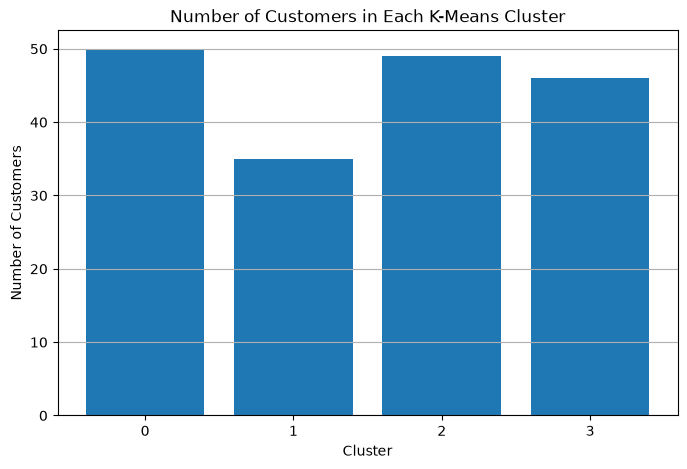

In [41]:
# Visualize cluster sizes

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each K-Means Cluster")
plt.grid(axis="y")

plt.show()


## Step 30: Final Cluster Evaluation


In [42]:
# Final silhouette score and inertia

final_silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

final_inertia = kmeans_final.inertia_

print("Final Silhouette Score:", round(final_silhouette, 4))
print("Final Inertia:", round(final_inertia, 4))


Final Silhouette Score: 0.088
Final Inertia: 5337.5651


## Step 31: Cluster Profiling


In [43]:
# Profile the main usage-related features

usage_features = [
    "Monthly_Charges",
    "Data_Usage_GB",
    "Support_Calls_Last_3M",
    "Tenure_Months"
]

available_usage_features = [
    feature
    for feature in usage_features
    if feature in df_clustered.columns
]

usage_profile = (
    df_clustered[
        available_usage_features + ["Cluster"]
    ]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

display(
    usage_profile.round(2)
)


,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
Cluster,,,,
0,74.65,18.21,3.30,37.00
1,77.61,17.23,2.89,44.10
2,70.07,18.63,3.20,38.80
3,78.04,17.02,2.85,37.35


## Step 32: Cluster Summary


In [44]:
# Cluster count and percentage

cluster_summary = pd.DataFrame({
    "Customer_Count": cluster_counts
})

cluster_summary["Percentage"] = (
    cluster_summary["Customer_Count"]
    / len(df_clustered)
    * 100
)

display(cluster_summary.round(2))


,Customer_Count,Percentage
Cluster,,
0,50,27.78
1,35,19.44
2,49,27.22
3,46,25.56


## Step 33: PCA for Visualization

PCA is used only to visualize the final K-Means clusters in two dimensions.


In [45]:
# PCA visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels

print(
    "Total explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)


Total explained variance: 0.1148


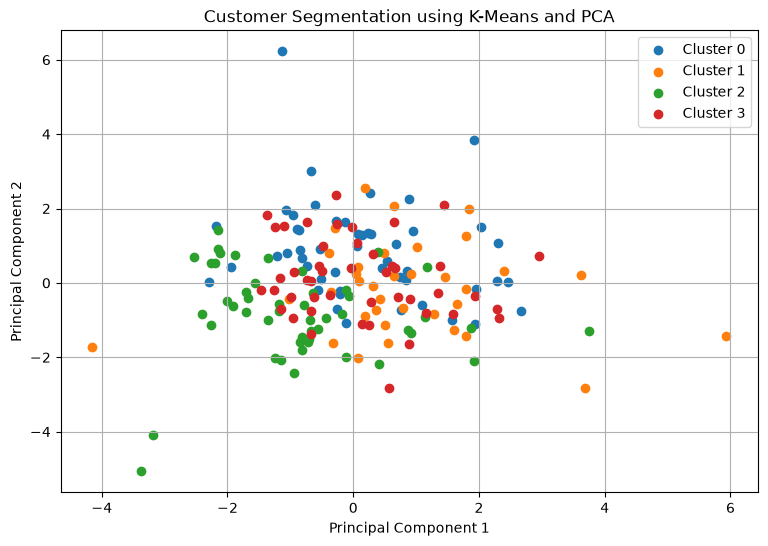

In [46]:
# Plot K-Means clusters using PCA

plt.figure(figsize=(9, 6))

for cluster in sorted(
    pca_df["Cluster"].unique()
):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means and PCA")
plt.legend()
plt.grid(True)

plt.show()


## Step 34: Final Results


In [47]:
# Final results

print("=" * 60)
print("FINAL K-MEANS RESULTS")
print("=" * 60)

print("\nProblem Statement:")
print(
    "Can we divide customers into groups based on "
    "their usage patterns?"
)

print("\nSelected K:", best_k)
print(
    "Final Silhouette Score:",
    round(final_silhouette, 4)
)

print("\nCluster Sizes:")
print(cluster_counts)

print("\nUsage Pattern Profile:")
display(
    usage_profile.round(2)
)


FINAL K-MEANS RESULTS

Problem Statement:
Can we divide customers into groups based on their usage patterns?

Selected K: 4
Final Silhouette Score: 0.088

Cluster Sizes:
Cluster
0    50
1    35
2    49
3    46
Name: count, dtype: int64

Usage Pattern Profile:


,Monthly_Charges,Data_Usage_GB,Support_Calls_Last_3M,Tenure_Months
Cluster,,,,
0,74.65,18.21,3.30,37.00
1,77.61,17.23,2.89,44.10
2,70.07,18.63,3.20,38.80
3,78.04,17.02,2.85,37.35


## Step 35: Business Interpretation

The cluster descriptions should be assigned from the actual cluster profile produced above.

Use the average values of:
- Monthly Charges
- Data Usage
- Support Calls
- Tenure

to describe what each cluster represents.


## Step 36: Conclusion

K-Means clustering was used to divide customers into groups based on their usage-related characteristics.

The dataset was cleaned, relationships between numerical variables were explored with a correlation heatmap, numerical distributions were examined with box plots, and possible outliers were detected and capped using the IQR method.

After encoding and feature scaling, K-Means was applied and the clusters were evaluated using the Elbow Method and Silhouette Score. PCA was then used to visualize the resulting customer groups.

The clustering results help identify customers with different usage patterns without using predefined target labels.
